# FineSightBench — Dataset Generation Validation

This notebook **tests and validates** dataset generation code:

1. **Difficulty mode** — size-based difficulty (original behaviour)
2. **Custom-count mode** — user-specified target counts (all tasks except `comparison`)
3. **Fixes demonstrated**:
   - `interference_cvd` / `interference_blur`: noise/blur is now applied to the **background only**; targets stay clean
   - `comparison`: two-step question (count + which is larger)
   - Two generation modes supported end-to-end

In [1]:
%matplotlib inline
import json, shutil, textwrap
from pathlib import Path
from collections import Counter

import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec
from PIL import Image, ImageDraw

from finesightbench.perception import generate_perception_dataset
from finesightbench.reasoning import generate_reasoning_dataset

CUSTOME_SIZE = 448


## 1. Difficulty mode — baseline generation

Generates both datasets iterating over `TARGET_SIZES` (1 target per sample except `comparison` which always uses 2).

In [2]:
out_root = Path("data/val_data")
if out_root.exists():
    shutil.rmtree(out_root)

p_labels = generate_perception_dataset(
    out_root / "perception",
    canvas_size=CUSTOME_SIZE, num_per_config=25, seed=49,
    mode="difficulty",
)
r_labels = generate_reasoning_dataset(
    out_root / "reasoning",
    canvas_size=CUSTOME_SIZE, num_per_config=25, seed=49,
    mode="difficulty",
)

p_data = json.loads(Path(p_labels).read_text())
r_data = json.loads(Path(r_labels).read_text())
print("perception samples:", len(p_data["samples"]))
print("reasoning  samples:", len(r_data["samples"]))
print("reasoning tasks:   ", r_data["dataset_info"]["task_types"])

[Perception] Generated 875 samples (mode=difficulty) -> data/val_data/perception
[Reasoning] Generated 1050 samples (mode=difficulty) -> data/val_data/reasoning
perception samples: 875
reasoning  samples: 1050
reasoning tasks:    ['comparison', 'counting', 'spatial', 'interference_cvd', 'interference_blur', 'chain_reasoning']


## 2. Fix #1 — interference applies to background only

Targets are crisp color blocks drawn on top of a textured background that has been
CVD-simulated (first row) or blurred (second row). The target itself is never distorted.

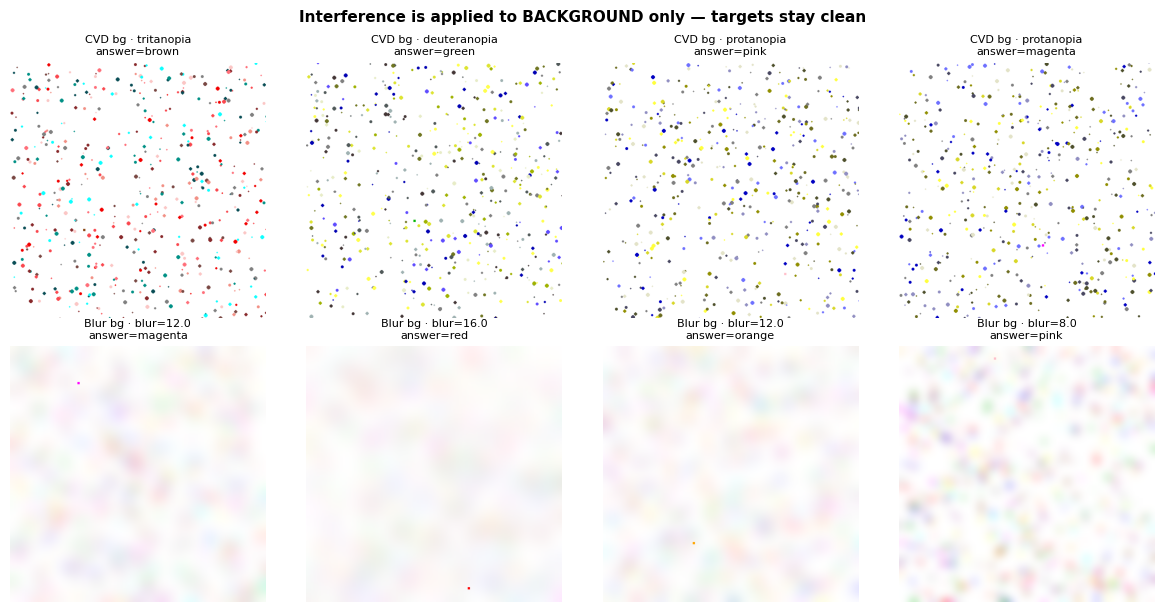

In [3]:
def samples_of(data, task, n=4):
    return [s for s in data["samples"] if s["task_type"] == task][:n]

r_root = out_root / "reasoning"

def show_row(ax_row, samples, title_prefix):
    for ax, s in zip(ax_row, samples):
        img = Image.open(r_root / s["image_path"])
        ax.imshow(img); ax.set_axis_off()
        extra = s["metadata"].get("extra", {})
        extra_txt = extra.get("cvd_type") or f"blur={extra.get('blur_radius')}"
        ax.set_title(f"{title_prefix} · {extra_txt}\nanswer={s['answer']}", fontsize=8)

fig, axes = plt.subplots(2, 4, figsize=(12, 6.2))
show_row(axes[0], samples_of(r_data, "interference_cvd"),   "CVD bg")
show_row(axes[1], samples_of(r_data, "interference_blur"),  "Blur bg")
fig.suptitle("Interference is applied to BACKGROUND only — targets stay clean",
             fontsize=11, fontweight="bold")
plt.tight_layout(); plt.show()

## 3. Fix #2 — `comparison` is a two-step question

First ask *how many objects*, then *which one is larger*. Answer format: `<count>; <left|right|same>`.

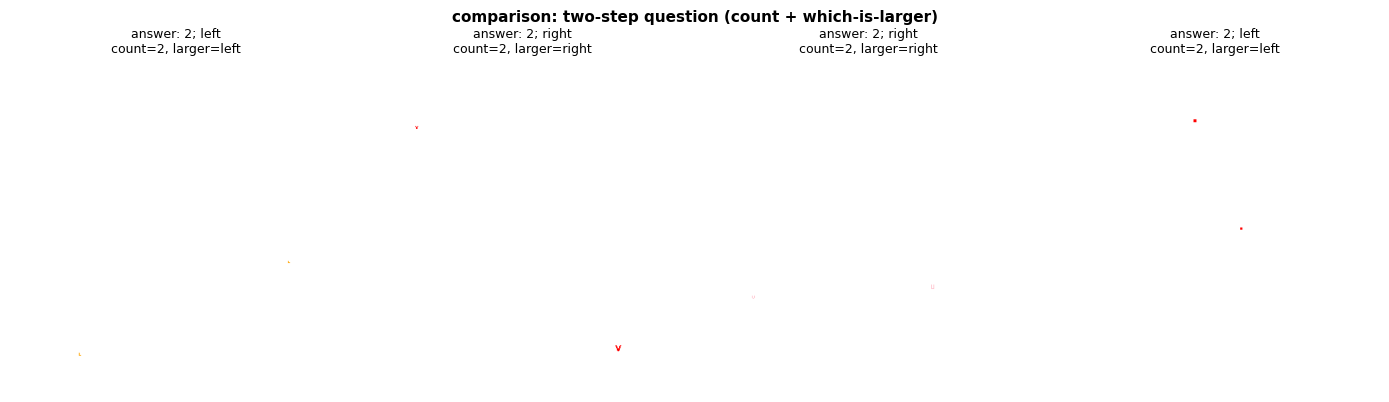


Question text example:
Answer two questions about the image. (1) How many objects are in the image? (2) Which one
is larger, the object on the left or the one on the right? Answer in the format: '<count>;
<left|right|same>'. Each object is an uppercase letter from: A, B, C, D, E, F, G, H, I, J,
K, L, M, N, O, P, Q, R, S, T, U, V, W, X, Y, Z.


In [4]:
cmp_samples = samples_of(r_data, "comparison", n=4)
fig, axes = plt.subplots(1, 4, figsize=(14, 4.2))
for ax, s in zip(axes, cmp_samples):
    img = Image.open(r_root / s["image_path"])
    ax.imshow(img); ax.set_axis_off()
    sub = s["metadata"]["sub_answers"]
    ax.set_title(
        f"answer: {s['answer']}\ncount={sub['count']}, larger={sub['larger']}",
        fontsize=9,
    )

fig.suptitle("comparison: two-step question (count + which-is-larger)",
             fontsize=11, fontweight="bold")
plt.tight_layout(); plt.show()

print("\nQuestion text example:")
print(textwrap.fill(cmp_samples[0]["question"], 90))

## 4. Fix #3 — custom-count mode

User specifies `counts=[...]` at a fixed `target_size`. All perception tasks and all
reasoning tasks *except* `comparison` participate.

In [6]:
p_custom_labels = generate_perception_dataset(
    out_root / "perception_custom",
    canvas_size=CUSTOME_SIZE, num_per_config=2, seed=7,
    mode="custom", counts=[2, 3, 5, 7], target_size=24,
)


r_custom_labels = generate_reasoning_dataset(
    out_root / "reasoning_custom",
    canvas_size=CUSTOME_SIZE, num_per_config=2, seed=7,
    mode="custom", counts=[2, 3, 5, 7], target_size=24,
)

p_custom = json.loads(Path(p_custom_labels).read_text())
r_custom = json.loads(Path(r_custom_labels).read_text())

print("perception custom tasks :", p_custom["dataset_info"]["task_types"])
print("reasoning  custom tasks :", r_custom["dataset_info"]["task_types"])
print("  (note: 'comparison' is correctly excluded from reasoning custom mode)\n")

by_task = Counter(s["task_type"] for s in r_custom["samples"])
print("reasoning custom sample counts per task:", dict(by_task))
print("num_targets values present:",
      sorted({s['metadata']['num_targets'] for s in r_custom['samples']}))

[Perception] Generated 40 samples (mode=custom) -> data/val_data/perception_custom
[Reasoning] Generated 40 samples (mode=custom) -> data/val_data/reasoning_custom
perception custom tasks : ['letter', 'animal', 'block', 'color_block', 'shape']
reasoning  custom tasks : ['counting', 'spatial', 'interference_cvd', 'interference_blur', 'chain_reasoning']
  (note: 'comparison' is correctly excluded from reasoning custom mode)

reasoning custom sample counts per task: {'counting': 8, 'spatial': 8, 'interference_cvd': 8, 'interference_blur': 8, 'chain_reasoning': 8}
num_targets values present: [2, 3, 5, 7]


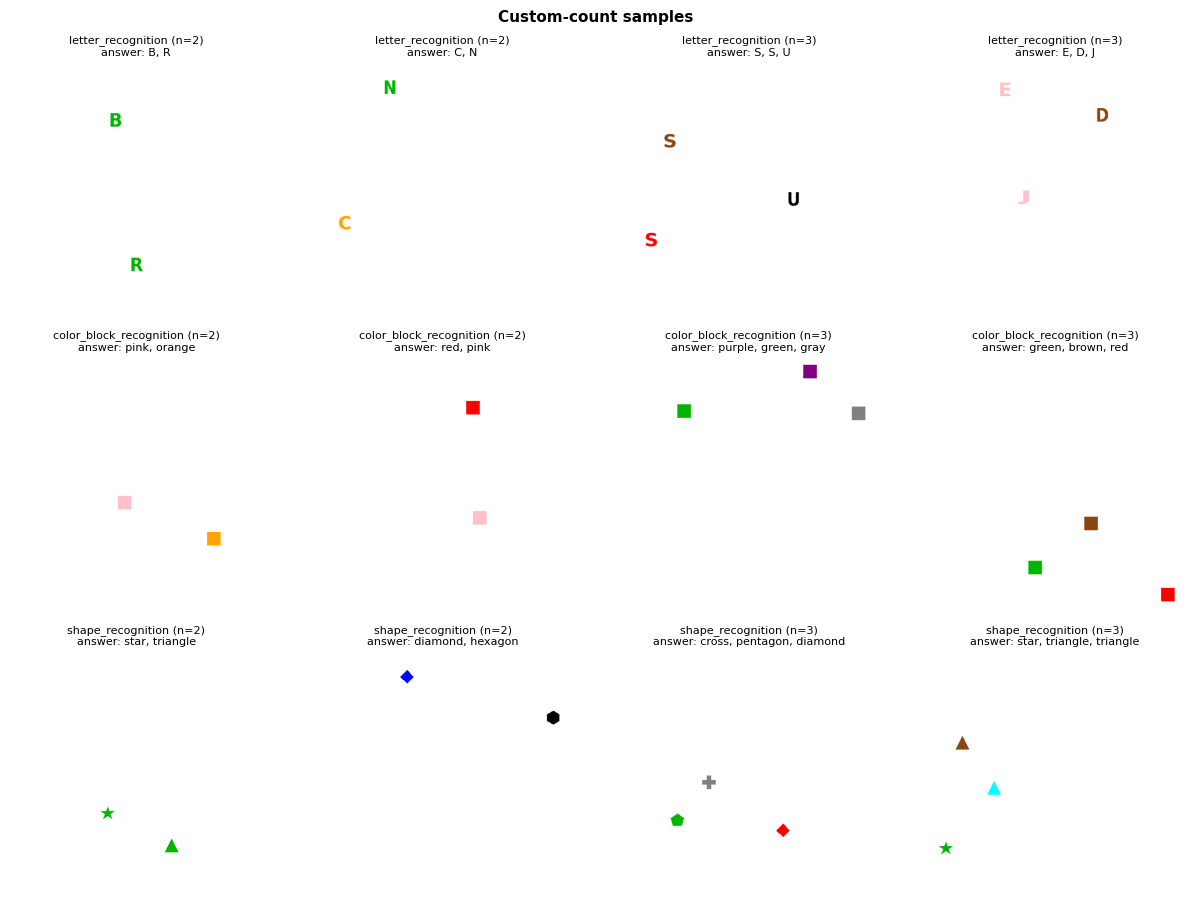

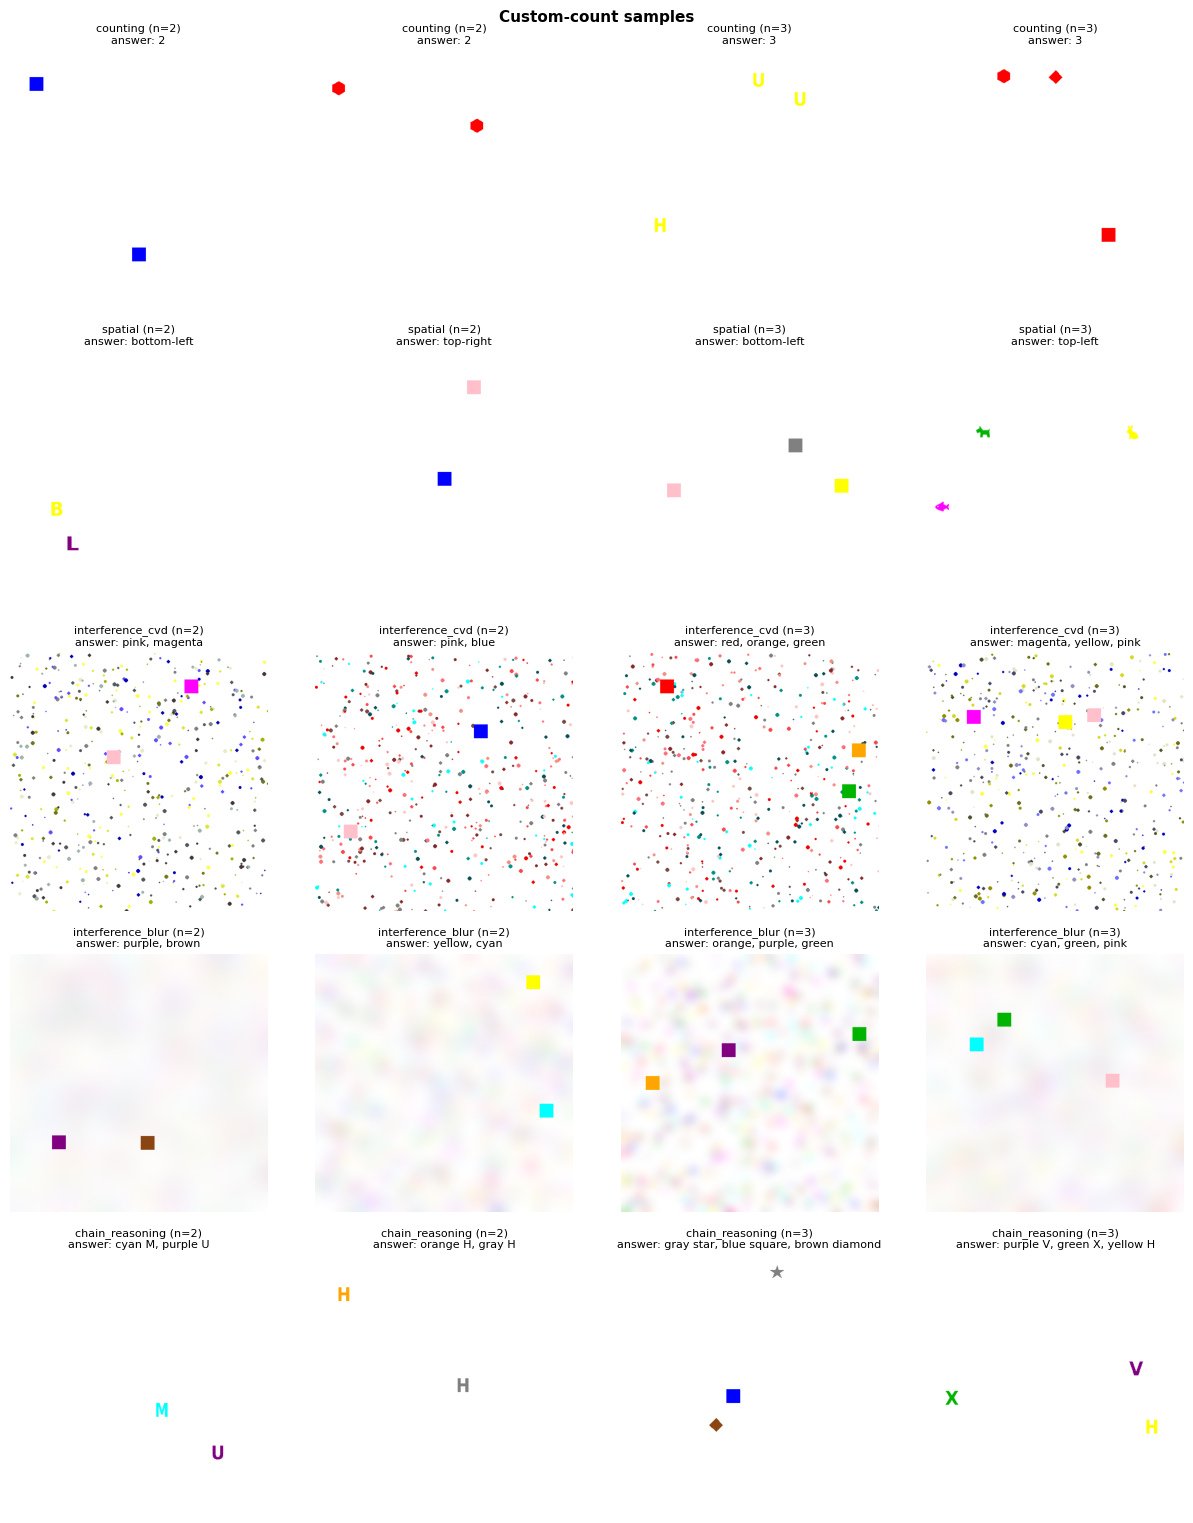

In [7]:
p_custom_root = out_root / "perception_custom"
r_custom_root = out_root / "reasoning_custom"

def grid_for(data, root, tasks, n_cols=4, max_chars=38):
    rows = len(tasks)
    fig, axes = plt.subplots(rows, n_cols, figsize=(3.1 * n_cols, 3.1 * rows))
    if rows == 1:
        axes = axes.reshape(1, -1)
    for r, task in enumerate(tasks):
        task_samples = [s for s in data["samples"] if s["task_type"] == task][:n_cols]
        for c, s in enumerate(task_samples):
            ax = axes[r, c]
            ax.imshow(Image.open(root / s["image_path"])); ax.set_axis_off()
            ans = s["answer"] if len(s["answer"]) <= max_chars else s["answer"][:max_chars] + "…"
            ax.set_title(f"{task} (n={s['metadata']['num_targets']})\nanswer: {ans}",
                         fontsize=8)
        for c in range(len(task_samples), n_cols):
            axes[r, c].set_axis_off()
    fig.suptitle("Custom-count samples", fontsize=11, fontweight="bold")
    plt.tight_layout(); plt.show()

grid_for(p_custom, p_custom_root,
         ["letter_recognition", "color_block_recognition", "shape_recognition"])
grid_for(r_custom, r_custom_root,
         ["counting", "spatial", "interference_cvd", "interference_blur", "chain_reasoning"])

Saved 8 images to data/val_data/images
Labels written to data/val_data/labels.json
PDF saved to data/val_data/val_rabbit_magnifier.pdf


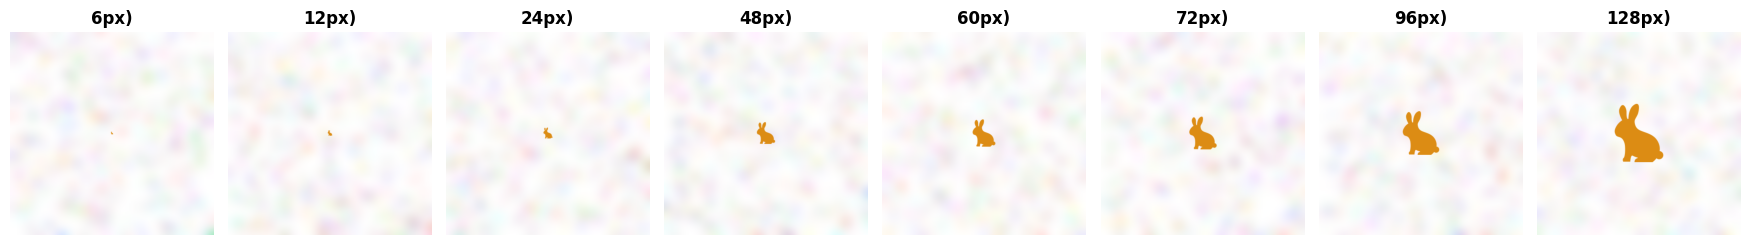

In [34]:
import json, math
from pathlib import Path
from PIL import ImageDraw
from finesightbench.core.canvas import create_canvas, create_textured_canvas
from finesightbench.core.colors import COLORS, apply_blur
from finesightbench.core.objects import TARGET_SIZES, draw_animal
from finesightbench.perception.generator import _difficulty

CANVAS = CUSTOME_SIZE
ANIMAL = "rabbit"
COLOR = (220, 140, 20)       # warm amber-gold rabbit
MAGNIFIER_COLOR = (45, 85, 175)  # deep indigo-blue magnifier
BLUR_RADIUS = 12.0
RING_PAD = 10
RING_WIDTH = 10

# Output directory
save_dir = Path("data/val_data")
img_dir = save_dir / "images"
img_dir.mkdir(parents=True, exist_ok=True)

def draw_magnifier_ring(img, cx, cy, radius, color=(45, 85, 175), width=3, handle_ratio=1.2):
    """Draw a magnifier (circle + diagonal handle) centred at (cx, cy)."""
    draw = ImageDraw.Draw(img)
    # --- lens ring ---
    for w in range(width):
        r = radius + w
        draw.ellipse([cx - r, cy - r, cx + r, cy + r], outline=color)
    # --- handle: starts at bottom-right of the circle, goes diagonally ---
    angle = math.radians(45)
    handle_len = int(radius * handle_ratio)
    hx0 = int(cx + (radius + width) * math.cos(angle))
    hy0 = int(cy + (radius + width) * math.sin(angle))
    hx1 = int(hx0 + handle_len * math.cos(angle))
    hy1 = int(hy0 + handle_len * math.sin(angle))
    for w in range(width + 1):
        draw.line([hx0 + w, hy0, hx1 + w, hy1], fill=color, width=1)
        draw.line([hx0, hy0 + w, hx1, hy1 + w], fill=color, width=1)

images = []
labels = []

TARGET_SIZES_NEW = [6, 12, 24, 48, 60, 72, 96, 128]
for size in TARGET_SIZES_NEW:
    # blurred textured background
    bg = create_textured_canvas(CANVAS, CANVAS, density=0.05)
    bg = apply_blur(bg, BLUR_RADIUS)
    # draw rabbit centered on top
    x = (CANVAS - size) // 2
    y = (CANVAS - size) // 2
    draw_animal(bg, (x, y), size, ANIMAL, COLOR)

    # draw magnifier ring + handle around rabbit
    # cx, cy = CANVAS // 2, CANVAS // 2
    # ring_r = size // 2 + RING_PAD
    # draw_magnifier_ring(bg, cx, cy, ring_r, color=MAGNIFIER_COLOR, width=RING_WIDTH)

    # save image
    image_id = f"val_{ANIMAL}_{size}px"
    fname = f"{image_id}.png"
    bg.save(img_dir / fname)

    labels.append({
        "image_id": image_id,
        "image_path": f"images/{fname}",
        "animal": ANIMAL,
        "size_px": size,
        "difficulty": _difficulty(size),
        "position": [x, y],
        "color": "amber-gold",
        "background": "textured+blurred",
        "blur_radius": BLUR_RADIUS,
    })
    images.append((size, bg.copy()))

# write labels.json
labels_path = save_dir / "labels.json"
labels_path.write_text(json.dumps({"samples": labels}, indent=2, ensure_ascii=False))
print(f"Saved {len(labels)} images to {img_dir}")
print(f"Labels written to {labels_path}")

# visualize & save PDF
fig, axes = plt.subplots(1, len(images), figsize=(2.2 * len(images), 2.8))
for ax, (size, img) in zip(axes, images):
    ax.imshow(img)
    ax.set_axis_off()
    ax.set_title(f"{size}px)", fontsize=12, fontweight="bold")

plt.tight_layout()

pdf_path = save_dir / "val_rabbit_magnifier.pdf"
fig.savefig(pdf_path, bbox_inches="tight")
print(f"PDF saved to {pdf_path}")

plt.show()

Loading google/vit-base-patch16-224 ...


Loading weights: 100%|██████████| 198/198 [00:00<00:00, 4717.31it/s]
ViTModel LOAD REPORT from: google/vit-base-patch16-224
Key                 | Status     | 
--------------------+------------+-
classifier.bias     | UNEXPECTED | 
classifier.weight   | UNEXPECTED | 
pooler.dense.weight | MISSING    | 
pooler.dense.bias   | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model loaded.
PDF saved to data/val_data/val_rabbit_rollout.pdf
